### Descriptive Statistics

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
#%matplotlib inline

_dataset = pd.read_csv('./data/sleep_health_and_lifestyle_dataset.csv')


custom_params = {
    "axes.spines.right": False,
    "axes.spines.top": False
}
sb.set_theme(style='ticks', palette='tab20c', rc=custom_params)
font = {
    'size': 16
}

In [2]:
dataset = _dataset.set_index('Person ID')

# creating and scrubing categories
gender_categories = dataset['Gender'].unique().tolist()

occupation_categories = dataset['Occupation'].unique().tolist()

dataset['BMI Category'].replace('Normal Weight', 'Normal', inplace=True)
bmi_categories = dataset['BMI Category'].unique().tolist()
if 'Underweight' not in bmi_categories:
    bmi_categories.append('Underweight')

dataset['Sleep Disorder'].fillna('None', inplace=True)
sleep_disorder_categories = dataset['Sleep Disorder'].unique().tolist()

gender_category = pd.api.types.CategoricalDtype(
    ordered=False, categories=gender_categories)
occupation_category = pd.api.types.CategoricalDtype(
    ordered=False, categories=occupation_categories)
bmi_category = pd.api.types.CategoricalDtype(
    ordered=False, categories=bmi_categories)
sleep_disorder_category = pd.api.types.CategoricalDtype(
    ordered=False, categories=sleep_disorder_categories)

dataset['Gender'] = dataset['Gender'].astype(gender_category)
dataset['Occupation'] = dataset['Occupation'].astype(occupation_category)
dataset['BMI Category'] = dataset['BMI Category'].astype(bmi_category)
dataset['Sleep Disorder'] = dataset['Sleep Disorder'].astype(
    sleep_disorder_category)

### Data Description

Sleep, weight and heart health data collected for 374 patients. Date of measurements are not included in the dataset.

#### Data collected per patient

| variable | description | data type |
| :--- | :--- | :--- |
| Gender | male/female | categorical, ordinal |
| Age | years | quantitative, continuous |
| Occupation | occupation or profession | categorical, nominal |
| Sleep Duration | hours/day | quantitative, continuous |
| Quality of Sleep | integer scale of 1-10, reported by patient | categorical, ordinal |
| Physical Activity Level | minutes/day | quantitative, continuous |
| Stress Level | integer scale of 1-10, reported by patient | categorical, ordinal |
| BMI Category | Underweight, Normal, Overweight, or Obese | categorical, nominal |
| Blood Pressure | systolic/diastolic | quantitative, continuous |
| Heart Rate | beats/min, resting | quantitative, discrete |
| Daily Steps | number of steps taken per day | quantitative, discrete |
| Sleep Disorder | None, Insomnia, Sleep Apnea | categorical, nominal |


- quantitative, continuous
- quantitative, discrete
- categorical, ordinal
- categorical, nominal



In [3]:
print('patients in study:', dataset.index.size, '\n')

print('categories')
print('Gender:', gender_categories)
print('Occupation:', occupation_categories)
print('BMI Category:', bmi_categories)
print('Sleep Disorder:', sleep_disorder_categories)

print('\nreindexed and categorized')

column_names = dataset.columns
for col_name in column_names:
    col = dataset[col_name]
    print(col_name, ':', col.dtype)

print('\ncontinuous variables:')
print('Age:', dataset['Age'].dtype)
print('Sleep Duration:', dataset['Sleep Duration'].dtype)
print('Physical Activity Level:', dataset['Physical Activity Level'].dtype)
print('Blood Pressure:', dataset['Blood Pressure'].dtype)
print('Heart Rate:', dataset['Heart Rate'].dtype)
# Age

print('\ninteger variables:')
print('Age:', dataset['Age'].dtype)
print('Quality of Sleep:', dataset['Quality of Sleep'].dtype)
print('Physical Activity Level:', dataset['Physical Activity Level'].dtype)
print('Heart Rate:', dataset['Heart Rate'].dtype)
print('Daily Steps:', dataset['Daily Steps'].dtype)
# Daily Steps

print('\nordinal categorical variables:')
print('Quality of Sleep:', dataset['Quality of Sleep'].dtype)
print('Stress Level:', dataset['Stress Level'].dtype)
# Stress Level

print('\nnominal categorical variables:')
print('Gender:', dataset['Gender'].dtype)
print('BMI Category:', dataset['BMI Category'].dtype)
print('Sleep Disorder:', dataset['Sleep Disorder'].dtype)
# Gender

print('\n', dataset.columns.values, '\n')

dataset.describe().to_csv()

patients in study: 374 

categories
Gender: ['Male', 'Female']
Occupation: ['Software Engineer', 'Doctor', 'Sales Representative', 'Teacher', 'Nurse', 'Engineer', 'Accountant', 'Scientist', 'Lawyer', 'Salesperson', 'Manager']
BMI Category: ['Overweight', 'Normal', 'Obese', 'Underweight']
Sleep Disorder: ['None', 'Sleep Apnea', 'Insomnia']

reindexed and categorized
Gender : category
Age : int64
Occupation : category
Sleep Duration : float64
Quality of Sleep : int64
Physical Activity Level : int64
Stress Level : int64
BMI Category : category
Blood Pressure : object
Heart Rate : int64
Daily Steps : int64
Sleep Disorder : category

continuous variables:
Age: int64
Sleep Duration: float64
Physical Activity Level: int64
Blood Pressure: object
Heart Rate: int64

integer variables:
Age: int64
Quality of Sleep: int64
Physical Activity Level: int64
Heart Rate: int64
Daily Steps: int64

ordinal categorical variables:
Quality of Sleep: int64
Stress Level: int64

nominal categorical variables:
Gen

',Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps\ncount,374.0,374.0,374.0,374.0,374.0,374.0,374.0\nmean,42.18449197860963,7.132085561497325,7.31283422459893,59.17112299465241,5.385026737967914,70.16577540106952,6816.844919786096\nstd,8.67313346554724,0.7956567308898188,1.1969559197336044,20.830803658071673,1.7745264441985167,4.135675535112214,1617.915679133637\nmin,27.0,5.8,4.0,30.0,3.0,65.0,3000.0\n25%,35.25,6.4,6.0,45.0,4.0,68.0,5600.0\n50%,43.0,7.2,7.0,60.0,5.0,70.0,7000.0\n75%,50.0,7.8,8.0,75.0,7.0,72.0,8000.0\nmax,59.0,8.5,9.0,90.0,8.0,86.0,10000.0\n'

### Typical Amount (Minutes) of Physical Activity

mean: 59.17112299465241
median: 60.0
mode: 0    60
Name: Physical Activity Level, dtype: int64
min: 30
max: 90
count    374.000000
mean      59.171123
std       20.830804
min       30.000000
25%       45.000000
50%       60.000000
75%       75.000000
max       90.000000
Name: Physical Activity Level, dtype: float64


Text(0, 0.5, 'Number of Patients')

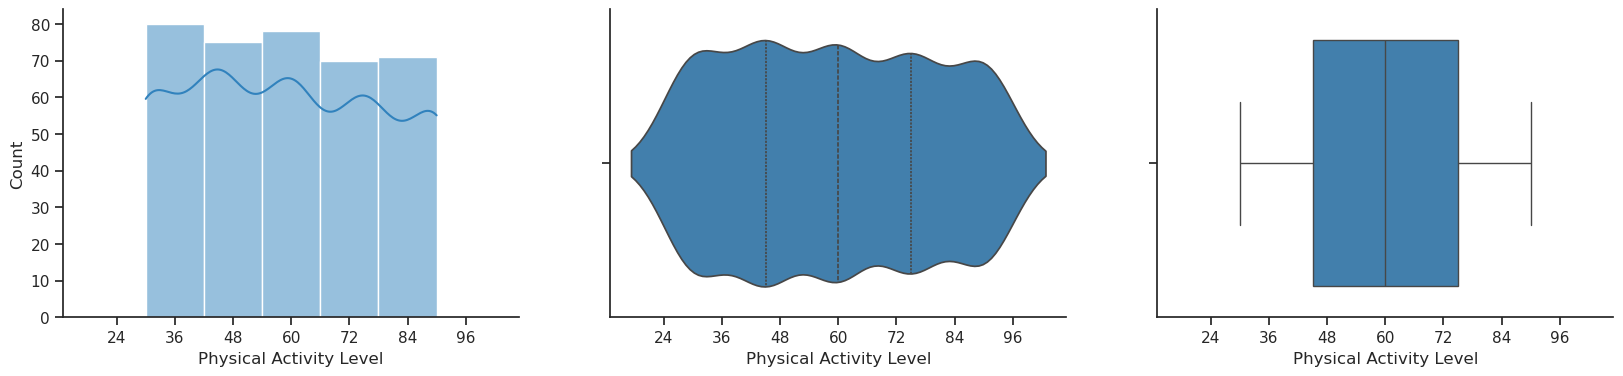

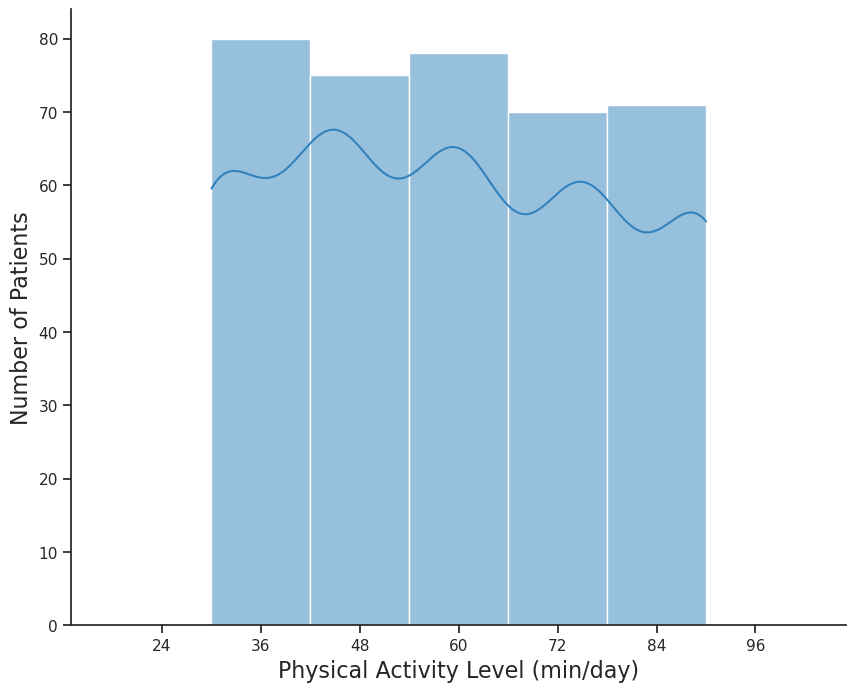

In [4]:
physical_activity_level = dataset['Physical Activity Level']

physical_activity_mean = physical_activity_level.mean()
physical_activity_median = physical_activity_level.median()
physical_activity_mode = physical_activity_level.mode()
physical_activity_min = physical_activity_level.min()
physical_activity_max = physical_activity_level.max()

print('mean:', physical_activity_mean)
print('median:', physical_activity_median)
print('mode:', physical_activity_mode)
print('min:', physical_activity_min)
print('max:', physical_activity_max)

print(physical_activity_level.describe())

plt.figure(figsize=[20, 4])

plt.subplot(1, 3, 1)
phys_activity_hist = sb.histplot(
    data=dataset,
    x='Physical Activity Level',
    kde=True,
    bins=5)
plt.xticks(np.arange(0, physical_activity_max+12, 12))

plt.subplot(1, 3, 2, sharex=phys_activity_hist.axes)
sb.violinplot(
    data=dataset,
    x='Physical Activity Level',
    inner='quartile')

plt.subplot(1, 3, 3, sharex=phys_activity_hist.axes)
sb.boxplot(
    data=dataset,
    x='Physical Activity Level')

plt.figure(figsize=[10, 8])
plt.subplot(1, 1, 1)
sb.histplot(
    data=dataset,
    x='Physical Activity Level',
    kde=True,
    bins=5)
plt.tick_params(labelsize=11)
plt.xticks(np.arange(0, physical_activity_max+12, 12))
plt.xlim(phys_activity_hist.get_xlim())
plt.xlabel(
    'Physical Activity Level (min/day)', fontdict=font)
plt.ylabel('Number of Patients', fontdict=font)

### Analysis of Daily Steps Taken

In [5]:
daily_steps = dataset['Daily Steps']
daily_steps_std = daily_steps.std()
daily_steps_max = daily_steps.max()
daily_steps_min = daily_steps.min()
daily_steps_range = daily_steps_max - daily_steps_min

print('standard deviation:', daily_steps_std)
print('max:', daily_steps_max)
print('min:', daily_steps_min)
print('range:', daily_steps_range)

print(daily_steps.describe())

standard deviation: 1617.915679133637
max: 10000
min: 3000
range: 7000
count      374.000000
mean      6816.844920
std       1617.915679
min       3000.000000
25%       5600.000000
50%       7000.000000
75%       8000.000000
max      10000.000000
Name: Daily Steps, dtype: float64


/home/mhaddock/miniconda3/envs/ai_prog_with_python/lib/python3.14/site-packages/seaborn/categorical.py:700: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  artists = ax.bxp(**boxplot_kws)


Text(0, 0.5, 'Number of Patients')

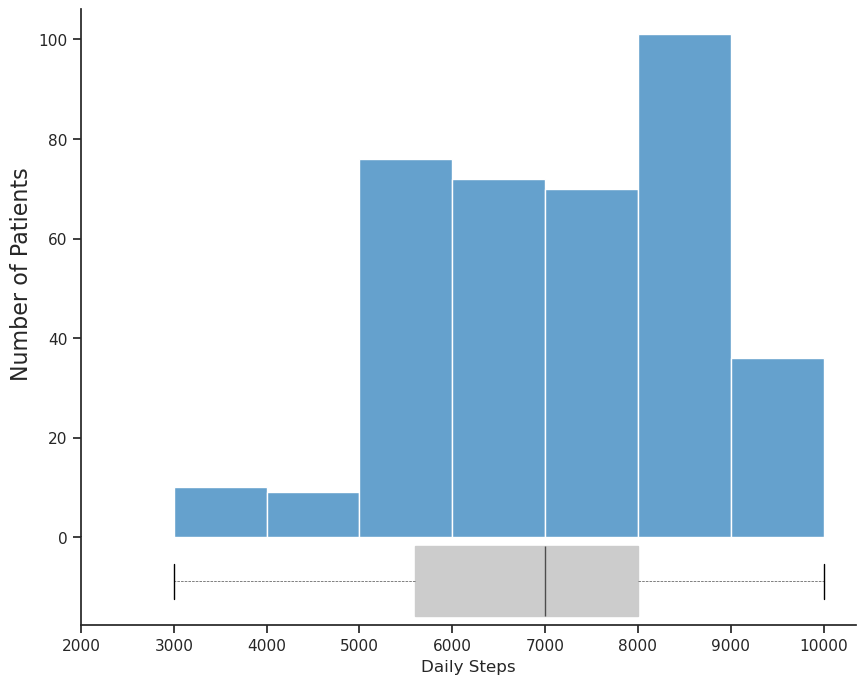

In [ ]:
num_hist_bins = 7
hist_bin_size = daily_steps_range / num_hist_bins

fig = plt.figure(figsize=[10, 8])
gs = fig.add_gridspec(2, hspace=0, height_ratios=[1, 1/6])
ax_top = fig.add_subplot(gs[0])
ax_bottom = fig.add_subplot(gs[1])
ax_bottom.sharex(ax_top)

sb.boxplot(
    data=dataset,
    x='Daily Steps',
    ax=ax_bottom,
    linewidth=1,
    color="0.5",
    whiskerprops={'linewidth': '0.5', 'linestyle': 'dashed'},
    capprops={'color': '0'},
    boxprops={'color': '0.8'}
)
ax_bottom.tick_params(
    labelsize=11,
    top=False, labeltop=False,
    left=False, labelleft=False,
    bottom=True, labelbottom=True)

sb.histplot(
    data=dataset,
    x='Daily Steps',
    bins=num_hist_bins,
    ax=ax_top
)

ax_top.tick_params(
    labelsize=11,
    top=False, labeltop=False,
    left=True, labelleft=True,
    bottom=False, labelbottom=False)
ax_top.spines.bottom.set_visible(False)
ax_top.set_xticks(np.arange(daily_steps_min - hist_bin_size,
                            daily_steps_max + hist_bin_size, hist_bin_size))
ax_top.set_xlabel('Daily Steps Taken', fontdict=font)
ax_top.set_ylabel('Number of Patients', fontdict=font)

### Distribution of Heart Rates

count    374.000000
mean      70.165775
std        4.135676
min       65.000000
25%       68.000000
50%       70.000000
75%       72.000000
max       86.000000
Name: Heart Rate, dtype: float64
median: 70.0
bins: [64. 65. 66. 67. 68. 69. 70. 71. 72. 73. 74. 75. 76. 77. 78. 79. 80. 81.
 82. 83. 84. 85. 86. 87.]


/home/mhaddock/miniconda3/envs/ai_prog_with_python/lib/python3.14/site-packages/seaborn/categorical.py:700: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  artists = ax.bxp(**boxplot_kws)


Text(0.5, 0, 'Heart Rate (bpm)')

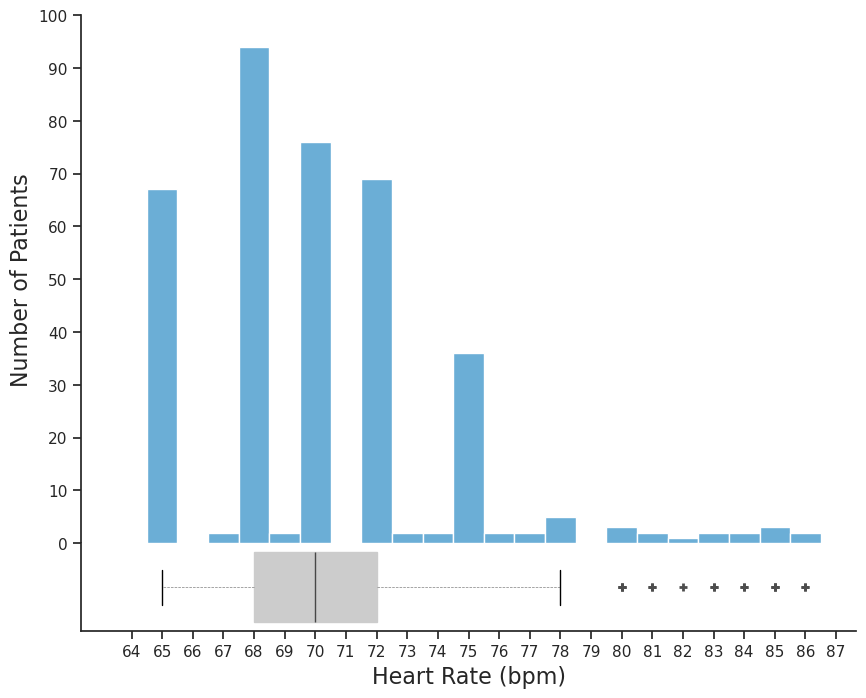

In [ ]:
heart_rate = dataset['Heart Rate']
print(heart_rate.describe())
print('median:', heart_rate.median())

heart_rate_range = heart_rate.max() - heart_rate.min()
hr_dist_num_bins = 21
hr_dist_bin_size = heart_rate_range / hr_dist_num_bins
hr_dist_bins = np.arange(
    heart_rate.min() - hr_dist_bin_size,
    heart_rate.max() + hr_dist_bin_size + 1,
    hr_dist_bin_size
)

print('bins:', hr_dist_bins)

hr_dist_fig = plt.figure(figsize=[10, 8])

hr_dist_gs = hr_dist_fig.add_gridspec(2, hspace=0, height_ratios=[1, 1/6])
hr_dist_ax_top = hr_dist_fig.add_subplot(hr_dist_gs[0])
hr_dist_ax_bottom = hr_dist_fig.add_subplot(hr_dist_gs[1])
hr_dist_ax_bottom.sharex(hr_dist_ax_top)

hr_dist_ax_top.hist(
    x=dataset['Heart Rate'],
    bins=hr_dist_bins,
    align='left',
    color='C1'
)

hr_dist_ax_top.tick_params(
    labelsize=11,
    top=False, labeltop=False,
    left=True, labelleft=True,
    bottom=False, labelbottom=False
)
hr_dist_ax_top.spines.bottom.set_visible(False)
hr_dist_ax_top.set_xticks(hr_dist_bins)
hr_dist_ax_top.set_xlabel('Heart Rate (BPM)', fontdict=font)
hr_dist_ax_top.set_yticks(np.arange(0, 101, 10))
hr_dist_ax_top.set_ylabel('Number of Patients', fontdict=font)

sb.boxplot(
    data=dataset,
    x='Heart Rate',
    ax=hr_dist_ax_bottom,
    linewidth=1,
    whiskerprops={'linewidth': '0.5', 'linestyle': 'dashed', 'color': '0.5'},
    capprops={'color': '0'},
    flierprops={'marker': '+', 'markerfacecolor': '0.5',
                'markeredgewidth': '2', 'markeredgecolor': '0.3'},
    boxprops={'color': '0.8'}
)
hr_dist_ax_bottom.tick_params(
    labelsize=11,
    top=False, labeltop=False,
    left=False, labelleft=False,
    bottom=True, labelbottom=True)

hr_dist_ax_bottom.set_xlabel('Heart Rate (bpm)', fontdict=font)

"On this slide, include a plot (graph) of the distribution of heart rates. What is the shape of the distribution? Are there any outliers?"

try log scale?
what is meant by 'normal' distribution

mean: 70.166
minimum: 65
1st quartile: 68
median: 70
3rd quartile: 72
maximum: 86

range: 21
inter-quartile range: 4
outliers: 15 patients reporting > 78 bpm. No patients fell into the lower outlier range
standard deviation: 4.135
